# Explore Buildings Data

Do the inspection lat/lon coords line up with buildings?

In [17]:
import os
import sys

import contextily as ctx
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from geopandas import GeoDataFrame
from shapely.geometry import box

sys.path.append("../utils")

import config

### Import SB buildings data

In [2]:
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

buildings = gpd.read_file(sb_buildings_path)

### Check whether inspection points line up with buildings

#### Import inspections

In [3]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections


# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [4]:
# Unpack from dictionary
inspections_2019 = inspections_dict[2019]
inspections_2020 = inspections_dict[2020]
inspections_2021 = inspections_dict[2021]
inspections_2022 = inspections_dict[2022]
inspections_2023 = inspections_dict[2023]

#### Count number of inspections that fall outside of buildings

In [5]:
# Create a function that returns the number of inspections that fall outside building geometries for a given year
def inspections_within_buildings(year):
    """
    Function to return the number of inspections that fall within building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    # Use left join to keep all inspections
    joined = inspections.sjoin(buildings, predicate="intersects", how="left")

    # Inspections within buildings have a non-null index_right
    intersects = joined[~joined["index_right"].isna()]
    # Inspections outside buildings have a null index_right
    outside = joined[joined["index_right"].isna()]

    return intersects.drop(columns=["index_right"]), outside.drop(
        columns=["index_right"]
    )


# For loop to print number of inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    inspections_within, inspections_outside = inspections_within_buildings(year)
    print(
        f"{year} Inspections: \nWithin Buildings - {inspections_within.shape[0]} \nOutside of Buildings - {inspections_outside.shape[0]}\n"
    )

2019 Inspections: 
Within Buildings - 11011 
Outside of Buildings - 3664

2020 Inspections: 
Within Buildings - 9528 
Outside of Buildings - 2350

2021 Inspections: 
Within Buildings - 10491 
Outside of Buildings - 3521

2022 Inspections: 
Within Buildings - 10157 
Outside of Buildings - 3485

2023 Inspections: 
Within Buildings - 9919 
Outside of Buildings - 3454



#### Count number of non-compliant inspections that fall outside of buildings

In [6]:
# For loop to print number of non-compliant inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    non_comp_inspections_in, non_comp_inspections_out = inspections_within_buildings(
        year
    )
    non_comp_inspections_in = non_comp_inspections_in[
        non_comp_inspections_in["status"] == "Non-Compliant"
    ]
    non_comp_inspections_out = non_comp_inspections_out[
        non_comp_inspections_out["status"] == "Non-Compliant"
    ]
    print(
        f"{year} Non-Compliant Inspections: \nWithin Buildings - {non_comp_inspections_in.shape[0]} \nOutside of Buildings - {non_comp_inspections_out.shape[0]}\n"
    )

2019 Non-Compliant Inspections: 
Within Buildings - 72 
Outside of Buildings - 51

2020 Non-Compliant Inspections: 
Within Buildings - 74 
Outside of Buildings - 20

2021 Non-Compliant Inspections: 
Within Buildings - 63 
Outside of Buildings - 7

2022 Non-Compliant Inspections: 
Within Buildings - 47 
Outside of Buildings - 13

2023 Non-Compliant Inspections: 
Within Buildings - 54 
Outside of Buildings - 17



## Assign inspections to nearby buildings

The minimum distance between buildings in CA is 10 feet (3.048 m). For this analysis, we will assign inspections to the closest building within 3 meters. 

In [7]:
# Assign inspections to buildings if the distance between them is < 3 meters
def assign_inspections_to_buildings(inspections, buildings, distance_threshold=3):
    """
    Function to assign inspections to buildings if the distance between them is less than the distance threshold.
    """
    # Make a copy to avoid SettingWithCopyWarning
    inspections = inspections.copy()

    # Create a Spatial Index for faster search
    sindex = buildings.sindex

    # Find the nearest geometry in buildings for each geometry in inspections
    inspections["nearest_geometry"] = inspections.geometry.apply(
        lambda x: buildings.iloc[sindex.nearest(x)[1][0]].geometry
    )

    # Calculate the distance to the nearest geometry
    inspections["distance_to_nearest"] = inspections.apply(
        lambda row: row.geometry.distance(row.nearest_geometry), axis=1
    )

    # Assign inspections to buildings if the distance is less than the threshold
    assigned_inspections = inspections[
        inspections["distance_to_nearest"] < distance_threshold
    ].copy()

    return assigned_inspections


assigned_inspections_2019 = assign_inspections_to_buildings(inspections_2019, buildings)
assigned_inspections_2020 = assign_inspections_to_buildings(inspections_2020, buildings)
assigned_inspections_2021 = assign_inspections_to_buildings(inspections_2021, buildings)
assigned_inspections_2022 = assign_inspections_to_buildings(inspections_2022, buildings)
assigned_inspections_2023 = assign_inspections_to_buildings(inspections_2023, buildings)

## Generate polygons for inspections without building geometries

For inspections missing building geometries, we will create polygons centered on the inspection points, using the average area of all inspected building geometries.

In [9]:
def process_inspections_by_year(year, buildings, distance_threshold=3):
    """
    Function to process inspections for a given year by:
    1. Importing the inspections data
    2. Performing spatial join with buildings
    3. For ALL unmatched inspections, assign them to the nearest building within the distance threshold
       or create a square geometry with the average building area
    4. Combine all processed inspections into a single dataset
    """
    # Import the inspections data for the year
    inspections = import_inspections_data(year)

    # Calculate the average building area
    avg_building_area = buildings.geometry.area.mean()
    side_length = np.sqrt(avg_building_area)  # Square root to get side length

    print(f"Average building area: {avg_building_area:.2f} square units")
    print(f"Square side length: {side_length:.2f} units")

    # Create a copy of buildings with just geometry for the join
    buildings_geom = buildings[["geometry"]].copy()

    # Perform spatial join with buildings
    inspections_with_buildings = inspections.sjoin(
        buildings_geom, predicate="intersects", how="left"
    )

    # Split into matched and unmatched
    matched_inspections = inspections_with_buildings[
        ~inspections_with_buildings["index_right"].isna()
    ].copy()
    unmatched_inspections = inspections_with_buildings[
        inspections_with_buildings["index_right"].isna()
    ].copy()

    # For matched inspections, replace point geometries with building polygons
    if not matched_inspections.empty:
        # Get indexes of matched buildings
        building_indexes = matched_inspections["index_right"].astype(int).tolist()

        # Get corresponding building geometries
        building_geometries = buildings.iloc[building_indexes].geometry.tolist()

        # Replace geometries
        matched_inspections.geometry = building_geometries

    # Create an empty list to store assigned inspections
    assigned_inspections_list = []
    # Create an empty list for inspections with new square geometries
    square_inspections_list = []

    # Process ALL unmatched inspections
    if not unmatched_inspections.empty:
        # For each unmatched inspection
        for idx, inspection in unmatched_inspections.iterrows():
            # Use the spatial index to find the nearest building
            nearest_idx = buildings.sindex.nearest(inspection.geometry)[1][0]
            nearest_building = buildings.iloc[nearest_idx]

            # Calculate the distance between the inspection and the nearest building
            distance = inspection.geometry.distance(nearest_building.geometry)

            # If within threshold, assign to this building
            if distance < distance_threshold:
                # Create a new row with inspection data and building geometry
                assigned_inspection = inspection.copy()
                assigned_inspection.geometry = nearest_building.geometry

                # Add to assigned inspections list
                assigned_inspections_list.append(assigned_inspection)
            else:
                # Create a square with area equal to the average building area
                # centered on the inspection point
                point = inspection.geometry
                x, y = point.x, point.y

                # Create a square centered on the point
                half_side = side_length / 2
                square = box(x - half_side, y - half_side, x + half_side, y + half_side)

                # Create a new row with inspection data and square geometry
                square_inspection = inspection.copy()
                square_inspection.geometry = square

                # Add to square inspections list
                square_inspections_list.append(square_inspection)

    # Convert lists to GeoDataFrames if any inspections were processed
    if assigned_inspections_list:
        assigned_inspections = gpd.GeoDataFrame(
            assigned_inspections_list, crs=inspections.crs
        )
    else:
        assigned_inspections = gpd.GeoDataFrame(
            columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
        )

    if square_inspections_list:
        square_inspections = gpd.GeoDataFrame(
            square_inspections_list, crs=inspections.crs
        )
    else:
        square_inspections = gpd.GeoDataFrame(
            columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
        )

    # Clean up columns
    matched_inspections = matched_inspections.drop(columns=["index_right"])

    # Combine all pieces - only add non-empty DataFrames
    dfs_to_concat = [
        df
        for df in [matched_inspections, assigned_inspections, square_inspections]
        if not df.empty
    ]
    result = pd.concat(dfs_to_concat)

    # Ensure it's a GeoDataFrame
    result = gpd.GeoDataFrame(result, geometry="geometry", crs=inspections.crs)

    # Print summary stats
    print(f"Year {year} summary:")
    print(f"  Original inspections: {len(inspections)}")
    print(f"  Matched with buildings: {len(matched_inspections)}")
    print(f"  Assigned to nearby buildings: {len(assigned_inspections)}")
    print(f"  Created square geometries: {len(square_inspections)}")
    print(f"  Total processed: {len(result)}")
    print()

    return result


# Process all years and store results in a dictionary
processed_inspections = {}
for year in range(2019, 2024):
    processed_inspections[year] = process_inspections_by_year(year, buildings)

# Save the processed datasets
for year, data in processed_inspections.items():
    output_path = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Assigned to nearby buildings: 725
  Created square geometries: 2939
  Total processed: 14675

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2020 summary:
  Original inspections: 11878
  Matched with buildings: 9528
  Assigned to nearby buildings: 586
  Created square geometries: 1764
  Total processed: 11878

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2021 summary:
  Original inspections: 14012
  Matched with buildings: 10491
  Assigned to nearby buildings: 668
  Created square geometries: 2853
  Total processed: 14012

Average building area: 284.05 square units
Square side length: 16.85 units


/tmp/ipykernel_195478/3107126012.py:116: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(dfs_to_concat)


Year 2022 summary:
  Original inspections: 13642
  Matched with buildings: 10157
  Assigned to nearby buildings: 652
  Created square geometries: 2833
  Total processed: 13642

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2023 summary:
  Original inspections: 13373
  Matched with buildings: 9919
  Assigned to nearby buildings: 625
  Created square geometries: 2829
  Total processed: 13373



## Compare original and processed inspections with plots

In [21]:
# Import SB County bounding box for plotting
sb_county = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
)

Average building area: 284.05 square units
Square side length: 16.85 units
Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Assigned to nearby buildings: 725
  Created square geometries: 2939
  Total processed: 14675



/tmp/ipykernel_195478/64071242.py:121: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(loc="upper right")
/tmp/ipykernel_195478/64071242.py:121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


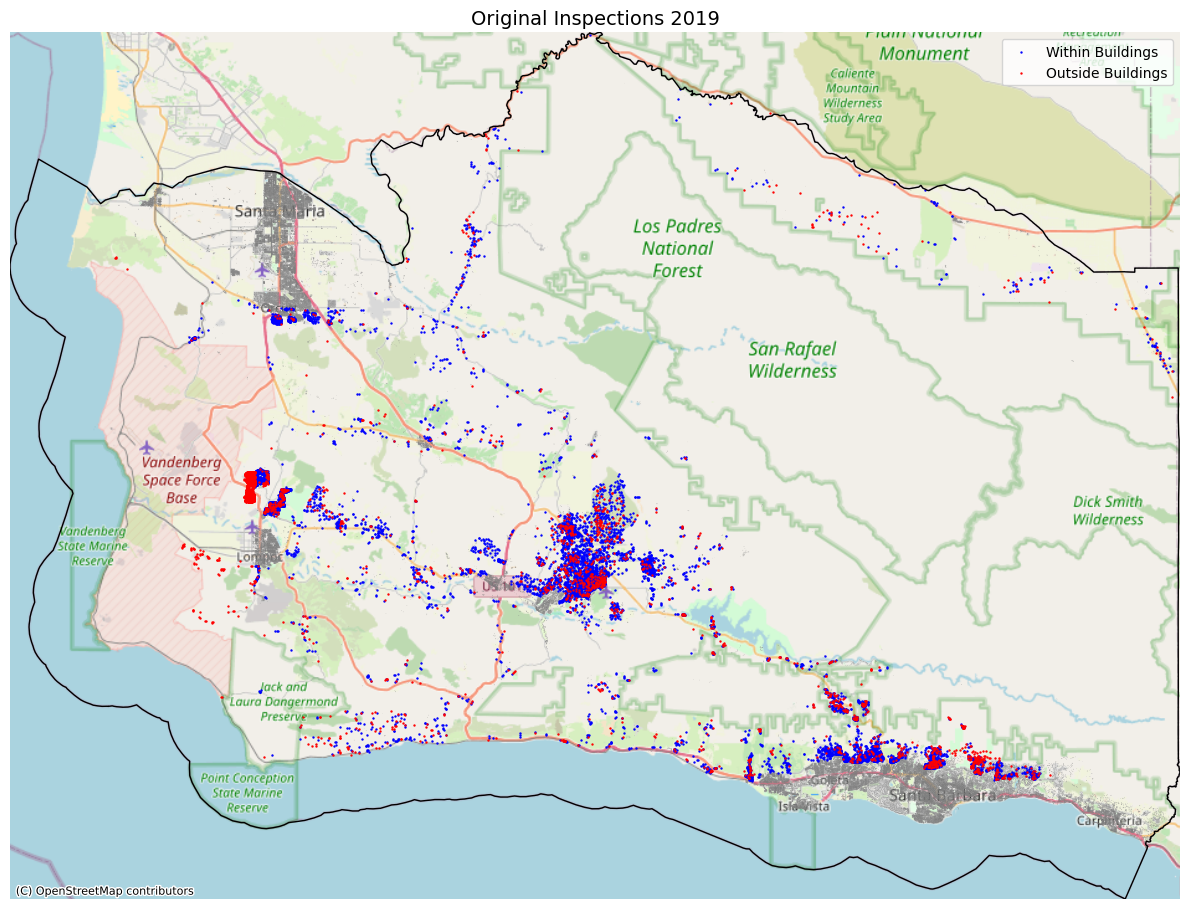

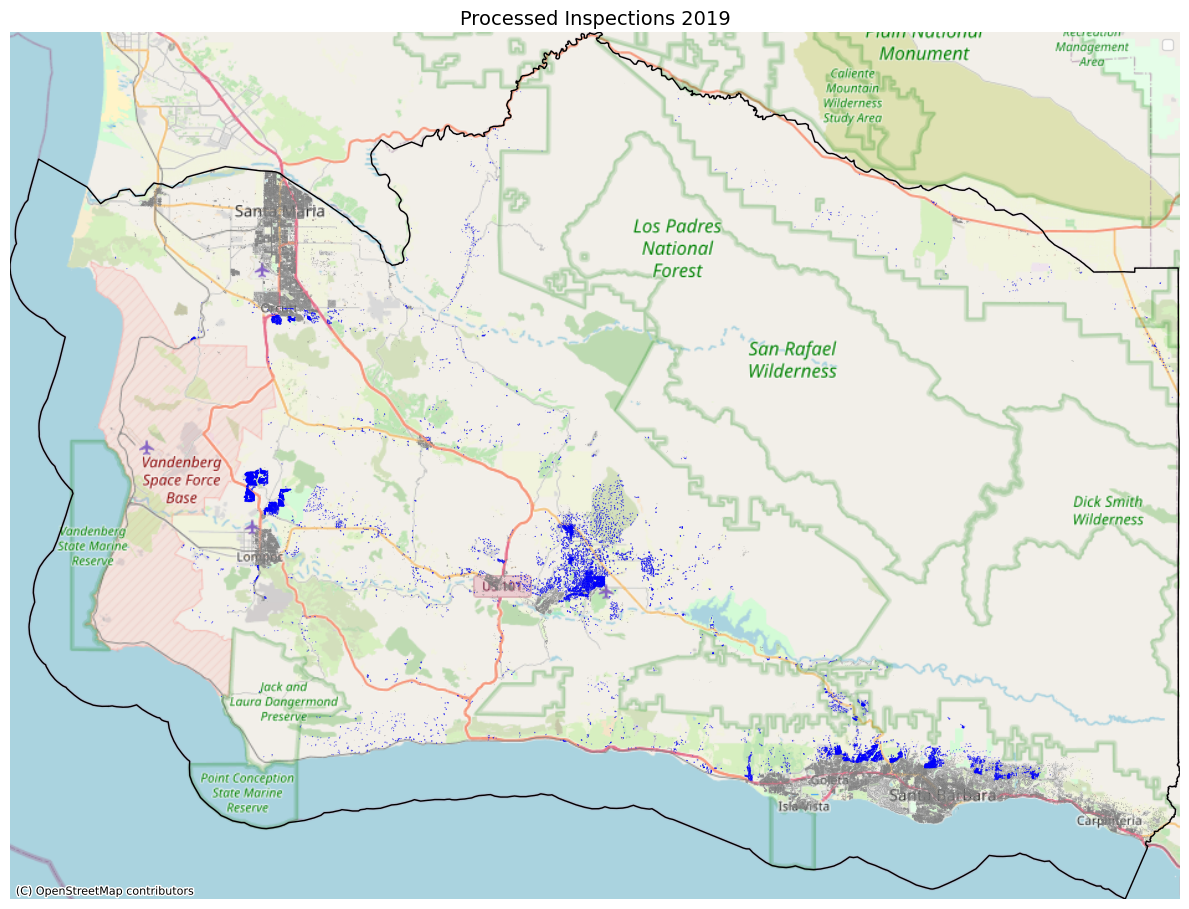

In [ ]:
def plot_inspection_processing_comparison(
    year, buildings, distance_threshold=3, sb_county=None
):
    """
    Function to create two separate plots comparing original and processed inspections
    with OpenStreetMap basemap

    Parameters:
    -----------
    year : int
        The year to plot data for
    buildings : GeoDataFrame
        Buildings data to use for processing
    distance_threshold : float
        Distance threshold used in processing
    sb_county : GeoDataFrame
        Santa Barbara County boundary for setting plot extent

    Returns:
    --------
    fig1, ax1, fig2, ax2 : matplotlib figure and axes objects for both plots
    """
    # Get original inspections within and outside buildings
    inspections_within, inspections_outside = inspections_within_buildings(year)

    # Process the inspections using our function
    processed_data = process_inspections_by_year(year, buildings, distance_threshold)

    # Create the first figure for original inspections
    fig1, ax1 = plt.subplots(figsize=(12, 10))

    # Make sure data is in the right projection for contextily
    buildings_projected = buildings.copy()
    inspections_within_projected = inspections_within.copy()
    inspections_outside_projected = inspections_outside.copy()
    sb_county_projected = sb_county.copy()

    # Check if reprojection is needed (contextily requires Web Mercator)
    if buildings.crs.to_string() != "EPSG:3857":
        buildings_projected = buildings.to_crs(epsg=3857)
        inspections_within_projected = inspections_within.to_crs(epsg=3857)
        inspections_outside_projected = inspections_outside.to_crs(epsg=3857)
        sb_county_projected = sb_county.to_crs(epsg=3857)

    # Set the plot extent to match the county boundary
    minx, miny, maxx, maxy = sb_county_projected.total_bounds
    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)

    # Plot the county boundary
    sb_county_projected.boundary.plot(ax=ax1, color="black", linewidth=1)

    # Plot original inspections
    buildings_projected.plot(
        ax=ax1, color="lightgray", alpha=0.5, edgecolor="gray", linewidth=0.3
    )
    inspections_within_projected.plot(
        ax=ax1, color="blue", markersize=0.5, label="Within Buildings"
    )
    inspections_outside_projected.plot(
        ax=ax1, color="red", markersize=0.5, label="Outside Buildings"
    )

    # Add basemap
    ctx.add_basemap(ax1, source=ctx.providers.OpenStreetMap.Mapnik)

    ax1.set_title(f"Original Inspections {year}", fontsize=14)
    ax1.legend(loc="upper right")

    # Create the second figure for processed inspections
    fig2, ax2 = plt.subplots(figsize=(12, 10))

    # Project processed data if needed
    processed_data_projected = processed_data.copy()
    if processed_data.crs.to_string() != "EPSG:3857":
        processed_data_projected = processed_data.to_crs(epsg=3857)

    # Set the plot extent to match the county boundary (same as first plot)
    ax2.set_xlim(minx, maxx)
    ax2.set_ylim(miny, maxy)

    # Plot the county boundary
    sb_county_projected.boundary.plot(ax=ax2, color="black", linewidth=1)

    # Plot the buildings and processed data
    buildings_projected.plot(
        ax=ax2, color="lightgray", alpha=0.5, edgecolor="gray", linewidth=0.3
    )

    # Plot processed points and polygons
    if "geometry" in processed_data_projected.columns:
        # Extract points and polygons
        points = processed_data_projected[
            processed_data_projected.geometry.type == "Point"
        ]
        polygons = processed_data_projected[
            processed_data_projected.geometry.type.isin(["Polygon", "MultiPolygon"])
        ]

        if not points.empty:
            points.plot(ax=ax2, color="blue", markersize=5, label="Point Geometries")

        if not polygons.empty:
            polygons.plot(
                ax=ax2,
                color="blue",
                alpha=0.6,
                edgecolor="blue",
                linewidth=0.7,
                label="Polygon Geometries",
            )

    # Add basemap to second plot
    ctx.add_basemap(ax2, source=ctx.providers.OpenStreetMap.Mapnik)

    ax2.set_title(f"Processed Inspections {year}", fontsize=14)
    ax2.legend(loc="upper right")

    # Remove axes for both figures
    ax1.axis("off")
    ax2.axis("off")

    # Adjust layout for both figures
    fig1.tight_layout()
    fig2.tight_layout()

    return fig1, ax1, fig2, ax2


# Plot for 2019
year = 2019
fig1, ax1, fig2, ax2 = plot_inspection_processing_comparison(
    year, buildings, sb_county=sb_county
)
plt.show()